In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. SETUP & HYPERPARAMETERS
# ==========================================
# Enforce float32 for faster execution on modern GPUs (e.g., M4)
tf.keras.backend.set_floatx('float32')

# Network Architecture
NN = 32          # Neurons per hidden layer
NL = 5           # Number of hidden layers
N_test = 20      # Number of test functions (Fourier modes)

# Training Parameters
N_epoch = 20000  # Total training iterations
batch_size = 128 # Number of random collocation points per step

# Physical Domain & Discretization
Time = 1.0       # Final time T
t_steps = 128    # Number of time increments
delta_t = Time / t_steps

# ==========================================
# 2. EXACT SOLUTIONS & PHYSICS DEFINITIONS
# ==========================================
def U_exact(x, t):
    """Analytic exact solution u(x,t) for validation."""
    return tf.exp(-t) * tf.sin(x) * tf.cos(x/2)

def U_x_exact(x, t):
    """Analytic exact spatial derivative u_x(x,t) for H1 error calculation."""
    return tf.exp(-t) * (tf.cos(x) * tf.cos(x/2) - 0.5 * tf.sin(x) * tf.sin(x/2))

def U_init(x):
    """Initial condition u(x,0)."""
    return tf.sin(x) * tf.cos(x/2)

def f_source(x, t):
    """
    Source term f(x,t) derived from the strong form PDE: u_t - u_xx = f.
    Based on the exact solution, substituting u_t and u_xx yields the forcing function.
    """
    u_val = tf.exp(-t) * tf.sin(x) * tf.cos(x/2)
    term2 = tf.exp(-t) * tf.cos(x) * tf.sin(x/2)
    return 0.25 * u_val + term2

# ==========================================
# 3. NEURAL NETWORK ARCHITECTURE
# ==========================================
class Cutoff(tf.keras.layers.Layer):
    """
    Custom layer to strictly enforce homogeneous Dirichlet boundary conditions.
    Multiplies the network output by x(x - pi) so that u=0 exactly at x=0 and x=pi.
    """
    def __init__(self, **kwargs):
        super(Cutoff, self).__init__()
        
    def call(self, inputs):
        x, u = inputs
        cut = x * (x - np.pi)
        return cut * u

def build_model():
    """Builds the fully connected neural network model."""
    X = tf.keras.layers.Input(shape=(1,), dtype='float32')
    
    L1 = tf.keras.layers.Dense(units=NN, activation='tanh')(X)

    # Add hidden layers
    for l in range(NL - 1):
        L1 = tf.keras.layers.Dense(units=NN, activation='tanh')(L1)
    
    # Output layer predicts all time steps simultaneously
    L_last = tf.keras.layers.Dense(units=t_steps, dtype='float32')(L1)
    
    # Apply hard boundary constraints
    L_out = Cutoff()([X, L_last])

    return tf.keras.Model(inputs=X, outputs=L_out, name='U_model')

U_model = build_model()
U_model.summary()

# ==========================================
# 4. VARIATIONAL LOSS FORMULATION
# ==========================================
class StochasticVariationalLoss(tf.keras.layers.Layer):
    """
    Custom layer calculating the PDE residual using a variational (weak) formulation.
    Integrals are approximated using a stochastic midpoint quadrature.
    """
    def __init__(self, U_model, batch_size, N_test, t_steps, U_init, delta_t, f_source, **kwargs):
        super(StochasticVariationalLoss, self).__init__()
        self.U_model = U_model
        self.batch_size = batch_size
        self.N_test = N_test
        self.dt = tf.constant(delta_t, dtype='float32')
        self.U_init = U_init
        self.f_source = f_source
        
        # Mathematical Constants
        self.pi = tf.constant(np.pi, dtype='float32')
        self.sqrt_2_pi = tf.constant(np.sqrt(2/np.pi), dtype='float32')

    @tf.function(jit_compile=False) 
    def call(self, inputs):
        
        # --- 1. Stochastic Quadrature Sampling ---
        # Generate random interior points, append boundaries, and sort to create intervals
        r = tf.random.uniform(shape=(self.batch_size,), minval=0.0, maxval=self.pi, dtype='float32')
        all_points = tf.concat([[0.0], r, [self.pi]], axis=0)
        unique_vals, _ = tf.unique(all_points)
        sorted_points = tf.stop_gradient(tf.sort(unique_vals))
        
        # Midpoints (S) and segment widths (W) for integration
        S = (sorted_points[:-1] + sorted_points[1:]) / 2
        W = sorted_points[1:] - sorted_points[:-1]
        S_in = S[:, None]

        # --- 2. Network Predictions & Gradient Computation ---
        with tf.GradientTape() as tape:
            tape.watch(S_in)
            u_pred = self.U_model(S_in) 
        
        # Compute spatial derivative u_x. 
        # batch_jacobian returns (Batch, Time, Features); we slice the feature dim.
        u_x = tape.batch_jacobian(u_pred, S_in)[:, :, 0]
        
        # Transpose outputs to (Time, Batch) to align with test functions for einsum
        u = tf.transpose(u_pred)
        u_x_t = tf.transpose(u_x)
        
        # --- 3. Dynamic Basis Construction ---
        k = tf.range(1, self.N_test + 1, dtype='float32')[:, None]
        
        # Test functions v (G) and v_x (H). Shape: (N_test, Batch)
        G = (1/k) * self.sqrt_2_pi * tf.sin(k * S[None, :])
        H = self.sqrt_2_pi * tf.cos(k * S[None, :])

        # --- 4. Source Term Evaluation ---
        # Evaluate forcing function on a space-time grid
        t_vals = tf.range(1, tf.shape(u)[0] + 1, dtype='float32') * self.dt
        S_grid, T_grid = tf.meshgrid(S, t_vals, indexing='xy')
        F_source = self.f_source(S_grid, T_grid)

        # --- 5. Implicit Euler Weak Form Assembly ---
        # PDE: u_t - u_xx = f. Weak Form: \int (u^n - u^{n-1})v + dt * \int u_x v_x - dt * \int f v = 0
        
        u0 = self.U_init(S)
        u_prev = tf.concat([u0[None, :], u[:-1, :]], axis=0)

        # Evaluate integrals using Einstein summation.
        # Indices: 't' (Time), 'b' (Batch/Quadrature Points), 'k' (Test Functions)
        I_u    = tf.einsum('tb,b,kb->tk', u, W, G)                  # \int u^n v dx
        I_prev = tf.einsum('tb,b,kb->tk', u_prev, W, G)             # \int u^{n-1} v dx
        I_grad = self.dt * tf.einsum('tb,b,kb->tk', u_x_t, W, H)    # dt * \int u_x v_x dx
        I_f    = self.dt * tf.einsum('tb,b,kb->tk', F_source, W, G) # dt * \int f v dx
        
        # Calculate squared residual matrix for all time steps and test functions
        loss_matrix = (I_u - I_prev + I_grad - I_f)**2

        # Sum over test functions and time steps (scaled by dt to approximate time integration)
        return tf.reduce_sum(loss_matrix) * self.dt

# ==========================================
# 5. VALIDATION & TRAINING INFRASTRUCTURE
# ==========================================
class ValidationCallback(tf.keras.callbacks.Callback):
    """Custom callback to compute exact L2 and H1 errors during training."""
    def __init__(self, interval=100):
        super(ValidationCallback, self).__init__()
        self.interval = interval
        self.history = {'relloss': [], 'epoch': [], 'L2': [], 'H1': []} 

        # Establish fixed validation grid for error integration
        self.x_val = tf.cast(tf.linspace(0.0, np.pi, 200)[:, None], 'float32')
        self.dx = self.x_val[1, 0] - self.x_val[0, 0]
        t_vals = tf.range(1, t_steps + 1, dtype='float32') * delta_t
        
        # Pre-compute analytic solution norms for relative error calculations
        self.u_exact = U_exact(self.x_val, t_vals[None, :]) 
        self.norm_L2_exact = tf.sqrt(tf.reduce_sum(self.u_exact**2) * self.dx * delta_t)
        
        self.u_x_exact = U_x_exact(self.x_val, t_vals[None, :])
        self.norm_H1_exact = tf.sqrt(tf.reduce_sum(self.u_x_exact**2) * self.dx * delta_t)

    def on_epoch_end(self, epoch, logs=None):
        """Calculates prediction errors at specified epoch intervals."""
        if (epoch + 1) % self.interval == 0:
            
            # Predict solution and gradient on the validation grid
            with tf.GradientTape() as tape:
                tape.watch(self.x_val)
                u_pred = U_model(self.x_val) 
            
            u_x_pred = tape.batch_jacobian(u_pred, self.x_val)[:, :, 0]
            
            # Compute discrete space-time L2 relative error
            diff_L2 = u_pred - self.u_exact
            err_L2 = tf.sqrt(tf.reduce_sum(diff_L2**2) * self.dx * delta_t)
            rel_L2 = err_L2 / self.norm_L2_exact
            
            # Compute discrete space-time H1 relative error
            diff_H1 = u_x_pred - self.u_x_exact
            err_H1 = tf.sqrt(tf.reduce_sum(diff_H1**2) * self.dx * delta_t)
            rel_H1 = err_H1 / self.norm_H1_exact

            relloss = logs['loss'] / self.norm_H1_exact
            
            # Store metrics for post-training plotting
            self.history['relloss'].append(relloss)
            self.history['epoch'].append(epoch + 1)
            self.history['L2'].append(rel_L2)
            self.history['H1'].append(rel_H1)

            print(self.norm_L2_exact)
            print(f"Epoch {epoch+1} | Loss: {relloss:.2e} | Rel L2: {rel_L2:.2e} | Rel H1: {rel_H1:.2e}")
            
def build_training_system():
    """Assembles the Keras Model mapping a dummy input to the variational loss scalar."""
    inputs = tf.keras.Input(shape=(1,), dtype='float32')
    
    loss_layer = StochasticVariationalLoss(
        U_model, batch_size, N_test, t_steps, U_init, delta_t, f_source
    )
    outputs = loss_layer(inputs)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Implement learning rate scheduler (Cosine/Exponential Decay)
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-2,
        decay_steps=500,
        decay_rate=0.9,
        staircase=True
    )
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # Use a dummy loss function because the true loss is generated by the custom layer
    model.compile(optimizer, loss=lambda y_true, y_pred: y_pred)
    return model

# ==========================================
# 6. EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    # Force execution on GPU device 0
    with tf.device('/GPU:0'):
        final_model = build_training_system()
        
        val_cb = ValidationCallback(interval=100)
        
        # The model only requires a dummy input to trigger the forward pass
        dummy = np.zeros((1,1), dtype=np.float32)
        
        print("Starting training loop...")
        history = final_model.fit(
            dummy, dummy,
            epochs=N_epoch,
            verbose=0, 
            callbacks=[val_cb]
        )

2026-02-24 20:43:12.714120: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-24 20:43:12.714139: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-24 20:43:12.714148: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-02-24 20:43:12.714161: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-24 20:43:12.714168: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "U_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │         64 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,056 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │      4,224 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cutoff (Cutoff)     │ (None, 128)       │          0 │ input_layer[0][0… │
│                     │                   │            │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,512 (33.25 KB)

 Trainable params: 8,512 (33.25 KB)

 Non-trainable params: 0 (0.00 B)

2026-02-24 20:43:13.386918: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 100 | Loss: 1.19e-03 | Rel L2: 9.55e-01 | Rel H1: 9.66e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 200 | Loss: 6.14e-04 | Rel L2: 9.14e-01 | Rel H1: 9.35e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 300 | Loss: 4.61e-04 | Rel L2: 8.83e-01 | Rel H1: 9.11e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 400 | Loss: 3.74e-04 | Rel L2: 8.56e-01 | Rel H1: 8.89e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 500 | Loss: 3.10e-04 | Rel L2: 8.27e-01 | Rel H1: 8.67e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 600 | Loss: 2.60e-04 | Rel L2: 8.00e-01 | Rel H1: 8.46e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 700 | Loss: 2.15e-04 | Rel L2: 7.71e-01 | Rel H1: 8.23e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 800 | Loss: 1.76e-04 | Rel L2: 7.40e-01 | Rel H1: 8.00e-01
tf.Tensor(0.58043706, shape=(), dtype=float32)
Epoch 900 | Loss: 1.44e-04 | Rel L2: 7.10e-01 | Rel H1: 7

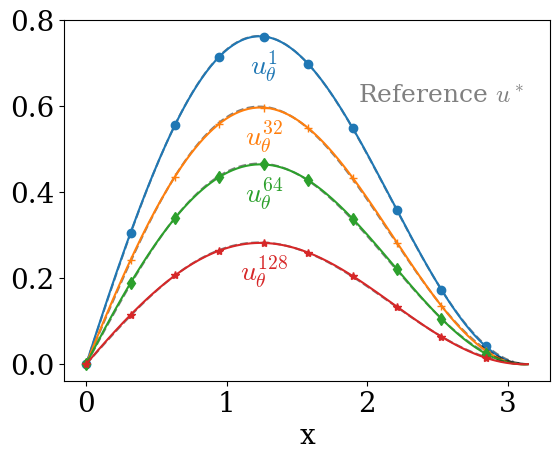

In [2]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
    
# ==========================================
# 1. PLOT CONFIGURATION
# ==========================================
# Global settings for publication-quality typography
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 20
rcParams['legend.fontsize'] = 20
rcParams['mathtext.fontset'] = 'cm' 
rcParams['axes.labelsize'] = 20

plt.figure(figsize=(6, 5))

# ==========================================
# 2. DATA PREPARATION
# ==========================================
# Generate high-resolution spatial grid for validation plotting
xlist = tf.cast(tf.linspace(0.0, np.pi, 200)[:, None], 'float32')

# Predict solution across all time steps and transpose to shape: (Time, Space)
uu = tf.transpose(U_model(xlist))

# Define specific time step indices to visualize (0-based indexing)
# These correspond to mathematical steps 1, 32, 64, and 128
steps = [0, 31, 63, 127]
m = ['o', '+', 'd', '*']

mid_idx = len(xlist) // 2 

# ==========================================
# 3. PLOTTING LOOP
# ==========================================
for i, t_idx in enumerate(steps):
    # Calculate physical time t for the exact solution evaluation
    t_val = (t_idx + 1) * delta_t
    
    # --- Plot Exact Solution (Reference) ---
    plt.plot(xlist, U_exact(xlist, t_val), 'k--', alpha=0.5)
    
    # Annotate the reference curve only once (on the first time step) to avoid clutter
    if i == 0:
        plt.text(xlist[-40], U_exact(xlist, t_val)[mid_idx] - 0.1, 
                 r'Reference $u^*$', color='gray', ha='center', va='bottom', fontsize=18)
        
    # --- Plot Neural Network Prediction ---
    # Format the mathematical label for the current time step prediction
    label_str = r'$u_{{\theta}}^{{{}}}$'.format(t_idx + 1)
    
    # Plot with markers spaced out (markevery=20) to maintain visibility of the dashed line
    lines = plt.plot(xlist, uu[t_idx, :], marker=m[i], markevery=20)
    line_color = lines[0].get_color()
    
    # Annotate the prediction curve with its specific time step label
    plt.text(xlist[-120], uu[t_idx, -120] - 0.11, label_str, 
             color=line_color, ha='center', va='bottom', 
             fontsize=20, fontweight='bold')

# ==========================================
# 4. FORMATTING & EXPORT
# ==========================================
plt.xlabel("$x$") 
plt.tight_layout()
plt.savefig("PaperEX1_solution_plot.pdf")
plt.show()

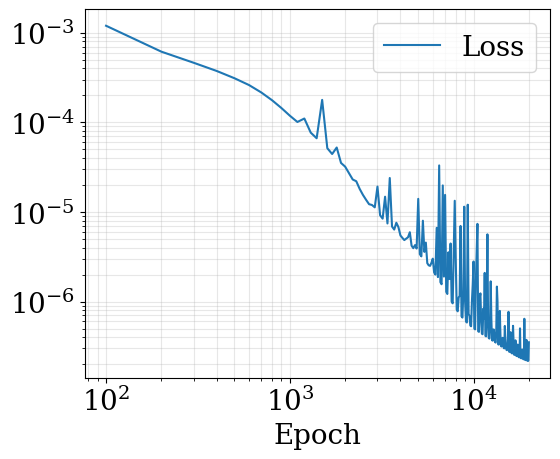

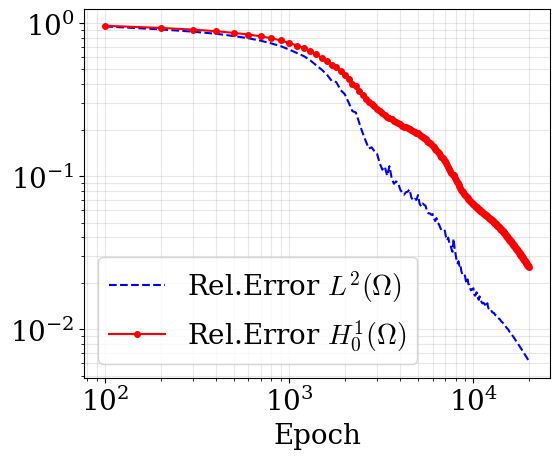

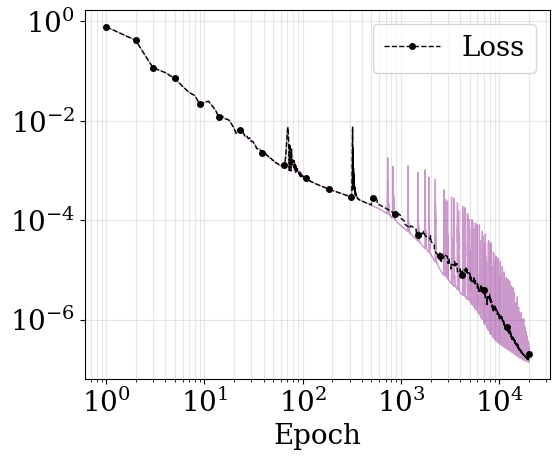

In [3]:
# ==========================================
# 1. VALIDATION LOSS (RAW)
# ==========================================
plt.figure(figsize=(6, 5))

# Plot the raw validation loss evaluated at discrete callback intervals
plt.loglog(val_cb.history['epoch'], val_cb.history['relloss'], label='Loss')

plt.xlabel("Epoch")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.savefig("PaperEX1_lossRaw.pdf")
plt.show()


# ==========================================
# 2. RELATIVE ERRORS (L2 and H1)
# ==========================================
plt.figure(figsize=(6, 5))

# Plot discrete space-time relative errors in L^2 and H^1_0 norms
plt.loglog(val_cb.history['epoch'], val_cb.history['L2'], '--b', markersize=4, label=r'Rel.Error $L^2(\Omega)$')
plt.loglog(val_cb.history['epoch'], val_cb.history['H1'], 'o-r', markersize=4, label=r'Rel.Error $H_0^1(\Omega)$')

plt.xlabel("Epoch")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.savefig("PaperEX1_error_plot.pdf")
plt.show()


# ==========================================
# 3. TRAINING LOSS (SMOOTHED)
# ==========================================
plt.figure(figsize=(6, 5))

# Extract full epoch-by-epoch training loss history
loss_data = np.array(history.history['loss'])
epochs = np.arange(1, len(loss_data) + 1)

# --- Smoothing Calculation ---
# Apply a moving average filter to visualize the convergence trend clearly.
window = 500
cutoff = 500  # The transition point: display raw loss before this epoch, smoothed loss after.

# Pad the array boundaries to prevent edge artifacts during convolution
padded_loss = np.pad(loss_data, (window//2, window//2), mode='edge')
weights = np.ones(window) / window

# Compute moving average using valid mode to prevent length mismatch
loss_smooth = np.convolve(padded_loss, weights, mode='valid')

# Trim slightly if necessary to guarantee exact length matching
loss_smooth = loss_smooth[:len(epochs)]

# Preserve the raw, unsmoothed data for the initial training phase
loss_smooth[:cutoff] = loss_data[:cutoff]

# --- Plotting ---
# Plot the transparent, raw loss history in the background
plt.loglog(epochs, loss_data, color='purple', alpha=0.4, linewidth=1, label=None)

# Define geometrically spaced target x-coordinates for markers.
# This prevents marker crowding on the right side of a log-log plot.
num_markers = 20
ideal_x = np.geomspace(epochs[0], epochs[-1], num_markers)

# Find the closest actual epoch indices to the ideal geometric spacing
marker_indices = np.searchsorted(epochs, ideal_x)

# Plot the smoothed line with perfectly distributed markers
plt.loglog(epochs, loss_smooth, 'o--k', 
           markevery=marker_indices, 
           markersize=4, 
           linewidth=1, 
           label='Loss')

plt.xlabel("Epoch")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.savefig("PaperEX1_loss_plot.pdf")
plt.show()